# The Articulation Story — §4.1–4.3 (v3: unsupervised metrics only)
*2026-08-10. Scope = the 1,032 unsupervised construct metrics (humor 284 / creative-writing 369 / math 141 / peer-review 88 / news 150). Supervised benchmarks (hotpot etc.) appear nowhere in this notebook.*

**Glossary:**
- **metric / construct** — one evaluation criterion mined from how communities talk about quality (e.g. 'Compressed, quotable phrasing').
- **unit** — one atomic checkable requirement inside a metric's definition (this notebook's 4.1 decomposition: 3,458 units, blind-labeled with 6/6-correct calibration anchors per annotator).
- **codable** — unit labeled MECHANICAL: checkable by simple code (counts, literal features, format). STRUCTURAL_CRAFT = needs semantic checking; TASTE = subjective judgment.
- **channel / text-segment category** — which part of an articulation the judge sees: `name`, `definition`, `definition_padded` (length control), `explanation`, `dossier`, `dossier_mismatched` (placebo), and `examples` (= `functional`: metric name + selected example texts, no definition).
- **judge capacity** — parameters of the model reading the articulation (1B→72B local; frontier = GLM-5.2 / gpt-oss-120b). Formerly 'receiver z'.
- **recovery** — balanced accuracy of the judge's verdicts vs the reference (majority of strong-model dossier-informed verdicts). Chance = .50.

**Reading rules:** notebook numbers are exploratory (all-probe); canonical numbers = the indexed artifacts. News z×a joins excluded (probe-universe landmine); crowd-panel news is self-consistent and included. Placebo-matched cells are anchoring, never content.

In [1]:
import glob, json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
D = "../outputs/articulation_story_20260810"
TASKS = ["humor", "creative_writing", "math", "peer_review", "news_homepages"]
ZTASKS = ["humor", "creative_writing", "math", "peer_review"]   # zxa-channel tasks (news excluded from joins)
def lp(p):
    if not os.path.exists(p): return {}
    z = np.load(p, allow_pickle=True)
    return {str(n): z["m_bar"][i] for i, n in enumerate([str(x) for x in z["names"]])}
def balanced(pred, lab):
    ok = (lab >= 0) & np.isfinite(pred)
    if ok.sum() < 30: return None
    p = (pred[ok] > .5).astype(int); l = lab[ok]
    accs = [float(np.mean(p[l == c] == c)) for c in (0, 1) if (l == c).sum() >= 5]
    return float(np.mean(accs)) if len(accs) == 2 else None
print("helpers ready")

helpers ready


## 4.1 Per-metric codability — what fraction of each metric's requirements can code check?

Each metric's definition was decomposed into atomic units and each unit blind-labeled. **% codable = share of the metric's units labeled MECHANICAL.** Left: every metric as a point (jittered), bars = per-task mean, dashed line = cross-task average. Right: the full per-metric distribution.

*(Aside on 'ANCH1..6' from the earlier draft: those were the six planted calibration anchors used to validate the original benchmark-unit tagger — validation rows, not metrics; they and the supervised benchmarks are gone from this notebook.)*

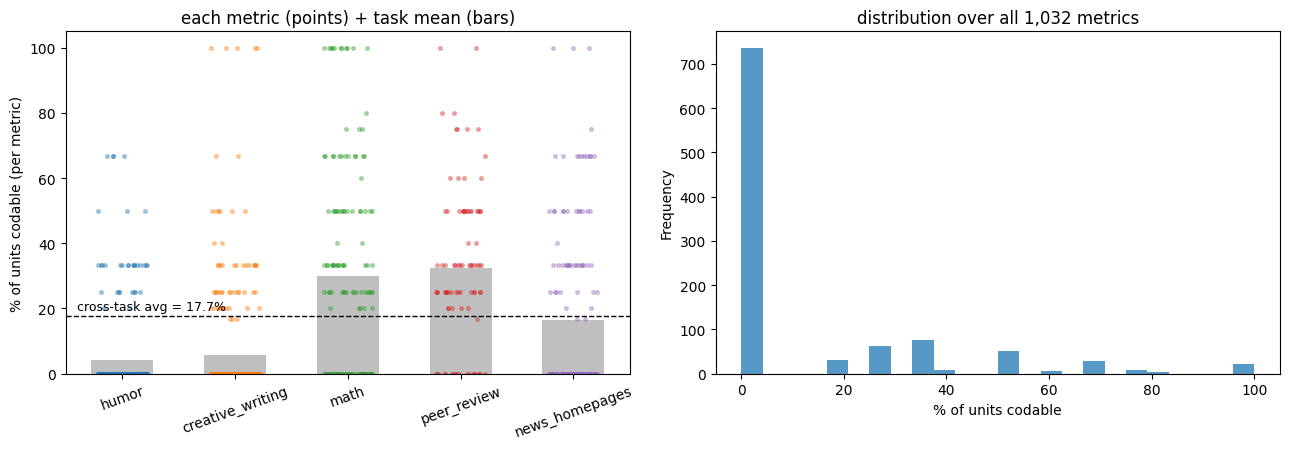

cross-task average % codable: 17.7%


,n_metrics,n_units,mean_pct_codable,pct_fully_uncodable,mean_pct_taste
task,,,,,
humor,284,968,4.2,88.4,30.7
creative_writing,369,1246,5.6,84.8,21.3
math,141,455,29.8,40.4,5.2
peer_review,88,331,32.3,22.7,6.9
news_homepages,150,458,16.4,64.0,10.2


In [2]:
cod = {}
for t in TASKS:
    d = json.load(open(f"{D}/code_metrics/unit_codability_{t}.json"))["metrics"]
    for name, units in d.items():
        labs = [u["label"] for u in units]
        cod[(t, name)] = {"n_units": len(labs),
                          "pct_codable": 100 * sum(l == "MECHANICAL" for l in labs) / len(labs),
                          "pct_taste": 100 * sum(l == "TASTE" for l in labs) / len(labs)}
dfc = pd.DataFrame([{"task": t, "metric": n, **v} for (t, n), v in cod.items()])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
rng = np.random.default_rng(0)
means = dfc.groupby("task")["pct_codable"].mean().reindex(TASKS)
for i, t in enumerate(TASKS):
    y = dfc[dfc.task == t]["pct_codable"].values
    axes[0].scatter(i + rng.uniform(-.22, .22, len(y)), y, s=7, alpha=.35)
axes[0].bar(range(len(TASKS)), means.values, width=.55, alpha=.25, color="k", zorder=0)
axes[0].axhline(means.mean(), color="k", ls="--", lw=1)
axes[0].text(-.4, means.mean() + 2, f"cross-task avg = {means.mean():.1f}%", fontsize=9)
axes[0].set_xticks(range(len(TASKS))); axes[0].set_xticklabels(TASKS, rotation=20)
axes[0].set_ylabel("% of units codable (per metric)")
axes[0].set_title("each metric (points) + task mean (bars)")
dfc["pct_codable"].plot(kind="hist", bins=24, ax=axes[1], alpha=.75)
axes[1].set_xlabel("% of units codable"); axes[1].set_title("distribution over all 1,032 metrics")
plt.tight_layout(); plt.show()
summ = dfc.groupby("task").agg(n_metrics=("metric", "count"), n_units=("n_units", "sum"),
                               mean_pct_codable=("pct_codable", "mean"),
                               pct_fully_uncodable=("pct_codable", lambda s: 100 * (s == 0).mean()),
                               mean_pct_taste=("pct_taste", "mean")).round(1).reindex(TASKS)
print(f"cross-task average % codable: {means.mean():.1f}%")
summ

## 4.2 Which parts of the prompt matter — every metric, then the mean

Left: per-metric recovery for each text-segment category — **one faint line per metric**, bold line = mean (judge = llama70b; z×a slate constructs, 4 tasks pooled; news excluded from these joins). Right: the same as box plots of the per-metric **gain over the bare name**.

Certified: gains are content not length (`definition_padded` ≈ `definition`), placebo at floor; `name` talkative-but-uninformative, `dossier` decisive-and-efficient (MI census).

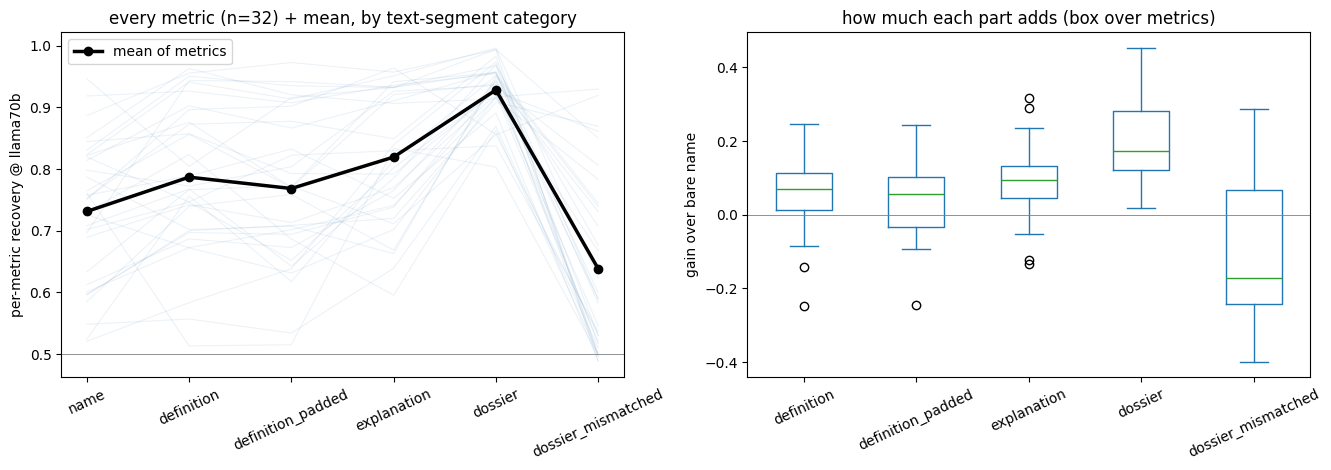

In [3]:
LADDER = ["llama1b","llama3b","qwen25-3b","qwen25-7b","llama8b","qwen25-14b",
          "gemma2-27b","qwen25-32b","llama70b","qwen25-72b"]
PAN = {t: {ex: lp(f"{D}/zxa_panels/mbar_zxa_{t}_{ex}.npz") for ex in LADDER} for t in ZTASKS}
GLMP = {t: {g: lp(f"{D}/zxa_panels/mbar_zxaglm_{t}_{g}.npz") for g in ("glm-47","glm-52")} for t in ZTASKS}
def ref_for(task, base):
    votes = []
    for src in (PAN[task].get("llama70b", {}), PAN[task].get("qwen25-72b", {}),
                GLMP[task].get("glm-47", {}), GLMP[task].get("glm-52", {})):
        r = src.get(base + "||dossier")
        if r is not None: votes.append((np.asarray(r, float) > .5).astype(float))
    if len(votes) < 2: return None
    m = np.nanmean(np.stack(votes), 0)
    return np.where(m > .5, 1, np.where(m < .5, 0, -1))
ARMS = ["name", "definition", "definition_padded", "explanation", "dossier", "dossier_mismatched"]
recs = []
for t in ZTASKS:
    bases = sorted({k.split("||")[0] for k in PAN[t].get("llama70b", {}) if not k.startswith("PLANTED")})
    for b in bases:
        lab = ref_for(t, b)
        if lab is None: continue
        row = {"task": t, "metric": b}
        for arm in ARMS:
            r = PAN[t]["llama70b"].get(f"{b}||{arm}")
            if r is not None:
                y = balanced(np.asarray(r, float), lab)
                if y is not None: row[arm] = y
        if "name" in row and "dossier" in row: recs.append(row)
df42 = pd.DataFrame(recs)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
xs = range(len(ARMS))
for _, r in df42.iterrows():
    axes[0].plot(xs, [r.get(a, np.nan) for a in ARMS], color="steelblue", alpha=.10, lw=.8)
axes[0].plot(xs, [df42[a].mean() for a in ARMS], color="k", lw=2.5, marker="o", label="mean of metrics")
axes[0].set_xticks(xs); axes[0].set_xticklabels(ARMS, rotation=25); axes[0].axhline(.5, color="gray", lw=.6)
axes[0].set_ylabel("per-metric recovery @ llama70b"); axes[0].legend()
axes[0].set_title(f"every metric (n={len(df42)}) + mean, by text-segment category")
gains = df42[["definition","definition_padded","explanation","dossier","dossier_mismatched"]].sub(df42["name"], axis=0)
gains.plot(kind="box", ax=axes[1], rot=25)
axes[1].axhline(0, color="gray", lw=.6); axes[1].set_ylabel("gain over bare name")
axes[1].set_title("how much each part adds (box over metrics)")
plt.tight_layout(); plt.show()

## 4.2a Examples vs definitions, and the judge-model effect

`definition` = show the written definition. `examples` (`functional`) = show the **name + selected example texts** instead. Wins below are holdout, at the judges that selected the examples; the winners are gestalt 'show-don't-tell' constructs. The three-judge comparison shows the same example sets are a **win** (selector), a **harm** (qwen25-72b, well-calibrated), or a **placebo** (gpt-oss — any examples fix its collapsed definition-reading; swapped examples work equally) — articulation value is a property of the construct–listener pair. Cross-receiver example *content* concentrates in **norm-boundary** metrics (blind-categorized, p=.006/.0095, LOO-robust).

metrics where examples beat the definition by >= .05 (best cell per metric):


,task,judge,definition,examples,delta
metric,,,,,
"Compressed, quotable phrasing",humor,llama70b,0.5511,0.8114,0.260
"Surprise, misdirection, and dual‑read clarity",humor,llama70b,0.6706,0.9059,0.235
"Delivery, timing, and commitment",humor,qwen25-72b,0.7361,0.9618,0.226
"Surprise, incongruity, and misdirection mechanics",humor,llama70b,0.6791,0.9002,0.221
Economy and Precision of Prose,creative_writing,llama70b,0.5718,0.7719,0.200
Observational/everyday‑life humor,humor,llama70b,0.6808,0.8808,0.200
Shared knowledge and reference accessibility,humor,qwen25-72b,0.5728,0.7529,0.180
Concrete imagery and vivid specificity,humor,llama70b,0.7491,0.9239,0.175
Cringe/awkwardness calibrated,humor,llama70b,0.7751,0.9234,0.148


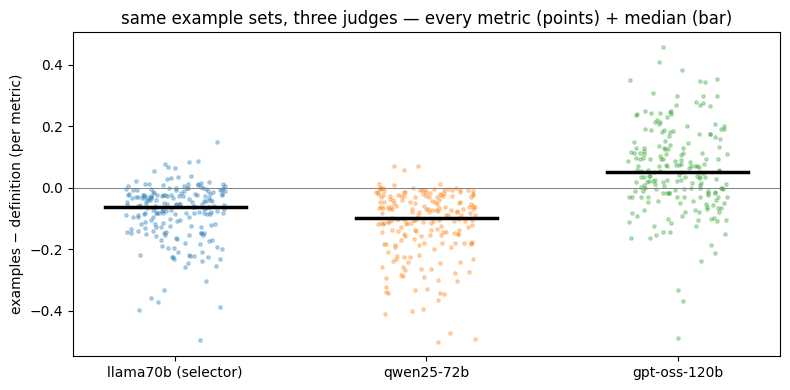

In [4]:
led70 = []
for s in ("llama70b", "qwen25-72b"):
    d = json.load(open(f"{D}/flips/flip_functional_v2_{s}.json"))["results"]
    for task, dd in d.items():
        if task == "news_homepages": continue
        for base, rec in dd.items():
            for obj, po in rec.get("objectives", {}).items():
                if obj == "null": continue
                h = po.get("holdout", {})
                if h.get("functional") is not None and h.get("definition") is not None:
                    led70.append({"task": task, "metric": base, "judge": s,
                                  "definition": h["definition"], "examples": h["functional"],
                                  "delta": round(h["functional"] - h["definition"], 3)})
df70 = pd.DataFrame(led70)
best = (df70.sort_values("delta", ascending=False).groupby("metric").first()
        .sort_values("delta", ascending=False))
print("metrics where examples beat the definition by >= .05 (best cell per metric):")
display(best[best.delta >= .05][["task", "judge", "definition", "examples", "delta"]])
led = json.load(open(f"{D}/analyses/v3sets_ledger_v1.json"))
rows = []
for rcv in ("qwen25-72b", "gpt-oss-120b"):
    for r in led[rcv]:
        rows.append({"judge": rcv, "metric": r["b"],
                     "examples_minus_definition": r["functional"] - r["definition"]})
v3h = json.load(open(f"{D}/flips/flip_functional_v3_llama70b.json"))["results"]["humor"]
for b, rec in v3h.items():
    h = rec["objectives"].get("frontier2v", {}).get("holdout", {})
    if h.get("functional") is not None and h.get("definition") is not None:
        rows.append({"judge": "llama70b (selector)", "metric": b,
                     "examples_minus_definition": h["functional"] - h["definition"]})
dfr = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8, 4))
order = ["llama70b (selector)", "qwen25-72b", "gpt-oss-120b"]
rng = np.random.default_rng(1)
for i, j in enumerate(order):
    y = dfr[dfr.judge == j]["examples_minus_definition"].values
    ax.scatter(i + rng.uniform(-.2, .2, len(y)), y, s=6, alpha=.3)
    ax.plot([i - .28, i + .28], [np.median(y)] * 2, color="k", lw=2.5)
ax.axhline(0, color="gray", lw=.7); ax.set_xticks(range(3)); ax.set_xticklabels(order)
ax.set_ylabel("examples − definition (per metric)")
ax.set_title("same example sets, three judges — every metric (points) + median (bar)")
plt.tight_layout(); plt.show()

## 4.3 Scaling laws — recovery vs judge capacity, split by saturation group

Full-bank curves from the crowd panels (each metric's own rubric read by every judge; qwen2.5 family shown — most rungs). Groups use the **corrected** saturation measure (the stored RISING/FLAT verdicts came from a retracted slope definition):
- **still gaining ('rising')** — top-vs-mid gain > .02 in ALL 3 families (asymptote unknown; n≈69)
- **plateaued** — gain ≤ .02 in ALL families (capability stopped helping)
- **family-dependent ('saturating')** — gaining in some families only

Each panel: one faint line per metric, bold = mean; dashed overlay = the **examples channel** (flip-ladder functional arm, same-family rungs, restricted to slate metrics in that group — humor/CW/math).

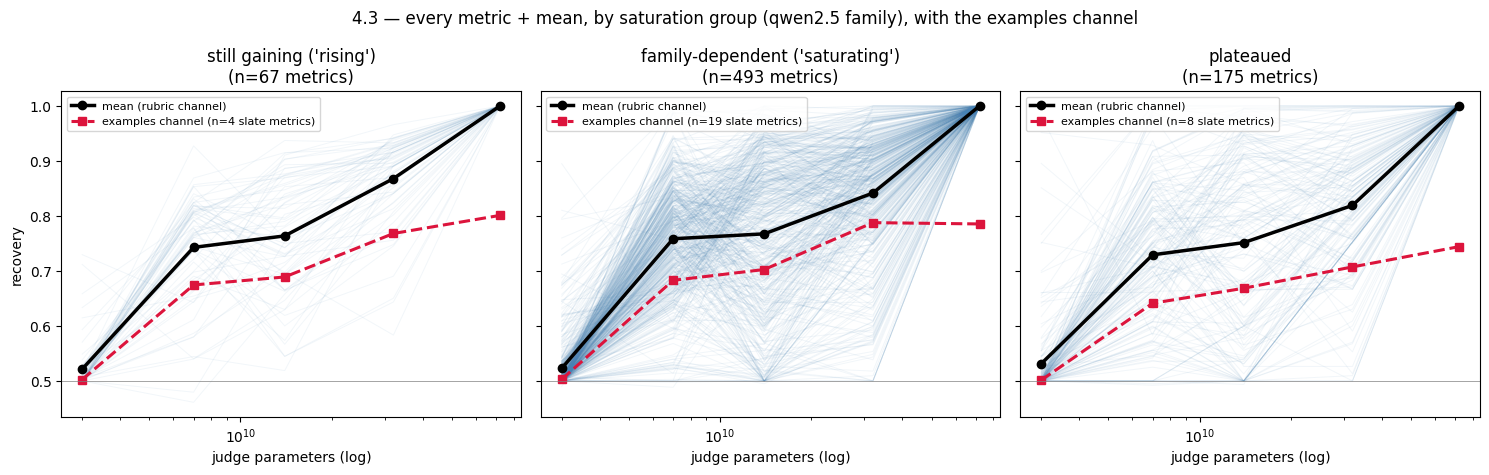

{"still gaining ('rising')": 67, "family-dependent ('saturating')": 493, 'plateaued': 175}


In [5]:
QF = ["qwen25-3b", "qwen25-7b", "qwen25-14b", "qwen25-32b", "qwen25-72b"]
QP = [3e9, 7e9, 14e9, 32e9, 72e9]
def crowd(task, ex):
    d = {}
    if task == "humor":
        d.update(lp(f"{D}/crowd_panels/mbar285_{ex}.npz")); d.update(lp(f"{D}/crowd_panels/mbar2_humor_sup_{ex}.npz"))
    else:
        d.update(lp(f"{D}/crowd_panels/mbar2_{task}_{ex}.npz"))
    return d
CR = {t: {ex: crowd(t, ex) for ex in QF + ["llama70b"]} for t in TASKS}
def cref(task, base):
    votes = []
    for ex in ("llama70b", "qwen25-72b"):
        r = CR[task].get(ex, {}).get(base)
        if r is not None: votes.append((np.asarray(r, float) > .5).astype(float))
    if len(votes) < 2: return None
    m = np.stack(votes).mean(0)
    return np.where(m > .5, 1, np.where(m < .5, 0, -1))
fj = json.load(open(f"{D}/analyses/family_verdict_join_v1.json"))["full_rows"]
def group_of(r, t=.02):
    tm = [v for v in r["top_minus_mid"].values() if v is not None]
    if len(tm) < 3: return None
    if all(v > t for v in tm): return "still gaining ('rising')"
    if all(v <= t for v in tm): return "plateaued"
    return "family-dependent ('saturating')"
GROUP = {(r["task"], r["name"]): group_of(r) for r in fj}
curves = {}
for r in fj:
    t, b = r["task"], r["name"]
    g = GROUP[(t, b)]
    if g is None: continue
    lab = cref(t, b)
    if lab is None: continue
    ys = []
    for ex in QF:
        v = CR[t].get(ex, {}).get(b)
        ys.append(balanced(np.asarray(v, float), lab) if v is not None else None)
    if sum(y is not None for y in ys) >= 4:
        curves.setdefault(g, []).append((t, b, ys))
# examples channel from the flip ladder (same qwen rungs), per group
lad = {ex: lp(f"{D}/flips/mbar_flipladder_{ex}.npz") for ex in QF}
mask = json.load(open(f"{D}/flips/flipladder_mask_v1.json"))
ex_curves = {}
for key in lad[QF[-1]]:
    if "functional_llama70b_frontier" not in key: continue
    t, rest = key.split("|", 1)
    b = rest.split("||")[0]
    g = GROUP.get((t, b))
    if g is None or t not in ZTASKS: continue
    lab = ref_for(t, b) if t in ZTASKS else None
    if lab is None: continue
    ys = []
    for ex in QF:
        r = lad[ex].get(key)
        ys.append(balanced(np.asarray(r, float), lab) if r is not None else None)
    if sum(y is not None for y in ys) >= 4:
        ex_curves.setdefault(g, []).append(ys)
GORDER = ["still gaining ('rising')", "family-dependent ('saturating')", "plateaued"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
for ax, g in zip(axes, GORDER):
    cs = curves.get(g, [])
    for t, b, ys in cs:
        xs = [p for p, y in zip(QP, ys) if y is not None]
        vy = [y for y in ys if y is not None]
        ax.semilogx(xs, vy, color="steelblue", alpha=.07, lw=.7)
    mean = [np.mean([ys[i] for _, _, ys in cs if ys[i] is not None]) for i in range(len(QF))]
    ax.semilogx(QP, mean, color="k", lw=2.5, marker="o", label="mean (rubric channel)")
    ec = ex_curves.get(g, [])
    if ec:
        em = [np.mean([ys[i] for ys in ec if ys[i] is not None]) for i in range(len(QF))]
        ax.semilogx(QP, em, color="crimson", lw=2.2, ls="--", marker="s",
                    label=f"examples channel (n={len(ec)} slate metrics)")
    ax.set_title(f"{g}\n(n={len(cs)} metrics)"); ax.axhline(.5, color="gray", lw=.5)
    ax.set_xlabel("judge parameters (log)"); ax.legend(fontsize=8)
axes[0].set_ylabel("recovery")
fig.suptitle("4.3 — every metric + mean, by saturation group (qwen2.5 family), with the examples channel")
plt.tight_layout(); plt.show()
print({g: len(curves.get(g, [])) for g in GORDER})

---
# Part B — the OSL week (2026-08-05 → 08-11): instruments, insights, and the §4 re-organization

*Everything below runs from repo-local data (`outputs/articulation_story_20260810/`, `outputs/analyses/`, `notebooks/data/2026-07-07-osl-multi/`). Part B has two halves: **B.1** replicates the observational-scaling-law (OSL) figures as currently printed in `latex/paper-2__articulation-upper-bounds/main.tex`, and **B.2** renders the new instruments built last week. **B.3** proposes the re-organized Section 4.*

## What we ran last week, and what each run taught us

| # | instrument (task) | artifact | insight |
|---|---|---|---|
| 1 | **Three-family saturation census** (task 3a) — llama + qwen2.5 + qwen3 staircases over the full 1,032-construct bank | `analyses/family_verdict_join_v1.json` | A construct's scaling verdict is **listener-family-relative**: only a minority of constructs get the same verdict in all three families; the family-dependent middle is the largest group. The dialect split is structured (Qwen owns prose-economy constructs; Llama owns performance/persona). |
| 2 | **Reference-reliability filter** (goal criterion 6) — screen every plateaued-everywhere construct's reference before calling it a ceiling | `outputs/analyses/reliability_filter_v1/` | A flat curve against a noisy reference is not a ceiling. The plateaued set splits into **130 reliable articulable-ceilings (12.6% of the universe)**, 189 plateau-at-low-recovery (never transmitted anywhere), and 43 reference-unreliable. |
| 3 | **De-censor test** (task 2b) — score the still-gaining tail with a frontier listener (gpt-oss-120b) vs the best clean local comparator (qwen3-32b) | `analyses/decensor_harvest_v1.json`, `flips/decensor_tail_v1.json` | The 69-construct still-gaining tail does **not** de-censor at the frontier under the local-dialect reference (mean −.134\*); 5 individual ceiling breaks stand as existence proofs. "Rising" reflects censoring by our ladder, but raw capability alone does not uncap it — the reference dialect binds. |
| 4 | **Frontier limit question** (goal criterion 3) — planted tacit constructs at gpt-oss-120b (headline, non-voter) and GLM-5.2 (corroborating, voter) | `analyses/frontier_limit_humor_v2.json` | **The gate opens; the gap never closes**: exemplars lift planted constructs +.20–.30\* above chance, yet exemplars-minus-definition stays negative (−.142\*) — demonstration content survives where restatement fails, even at the strongest receiver. Corroborated on math (GLM leg: ex−def −.093\*, gates +.17\*). |
| 5 | **Channel × capability at bank scale** (goal criterion 2) — rubric channel over 11 local receivers, examples channel at 3, per blind construct-category, leave-one-out references | `outputs/analyses/channel_scale_v2/` | Recovery is a function of **(z, channel, construct class)**, not z alone. Capacity gains (72B−3B) are +.196\*/+.228\*/+.217\* for mechanics/norm-boundary/other; norm-boundary climbs slower and catches up only at 72B. |
| 6 | **Examples-at-scale program** (tasks 1c/1c-FULL) — 222 flip-selected exemplar sets × two receivers, with donor-swapped (mm) controls | `analyses/v3sets_ledger_v1.json`, `analyses/metric_categories_blind_v1.json` | Two faces of examples-help: at a well-calibrated receiver (qwen2.5-72B) exemplars carry a **tiny real cross-receiver content** signal (+.0135\*); at gpt-oss-120b they mostly **re-calibrate a collapsed definition-decoder** (anchoring +.0628\*, content ≈ 0). Exemplar content concentrates in **norm-boundary** constructs (blind categorization; rank tests p=.006/.0095). |
| 7 | **Mutual-information upper-bound census** (user-requested) — H(pred) of every decoder channel | `analyses/mi_upper_census_v2.json` | Every readout is bounded by its channel entropy; **degeneracy is capability-graded** (qwen2.5-3b emits 89–100% constant predictions → the ladder floors are channel collapse, not construct absence). The census doubles as an instrument-health monitor (it caught the phi4 parser invalidity). |
| 8 | **Verdict/remedy table** (goal criterion 4) — every construct assigned its Collins remedy | `outputs/analyses/verdict_table_v1/` | 1,032 constructs → **60.1% dialect-matched-listener / 35.1% works-as-stated / 4.4% better-demonstration / 0.5% stronger-listener**. The dominant remedy is not "a bigger model" but "a listener that shares the reference dialect." |
| 9 | **Ladder validation** (goal criterion 5) — rungs frozen from full-bank data, then scored against the preregistered abstractness predictions P1–P3 | `outputs/analyses/ladder_p123_v1/` | The operational ladder **does not reduce to lexical abstractness** (prereg landing zone 3): P1 concreteness runs the *wrong way within every domain* (harder-to-transmit constructs are worded MORE concretely); P2 beyond-text constructs are commonest at rung 1; R3 is empty (examples are additive, never the primary channel). |

The through-line: the paper's current §4 treats recovery as a curve in one variable (capability z) and classifies constructs by curve shape. The week's instruments show every one of those curve shapes is **conditional on the listener family, the reference dialect, and the articulation channel** — and give us certified tools to say which ceilings are real, which "rising" curves are censoring, and what remedy each construct actually needs.

## B.1 Replicas of the current paper figures (Section 4 + Tables 1–2)

Matplotlib replicas of the OSL figures as they stand in `main.tex`, from the same data files the TikZ generators consume. Diagram-style figures (tacit-iso, code-iso, the pipeline schematics) are hand-drawn TikZ and are not replicated here.

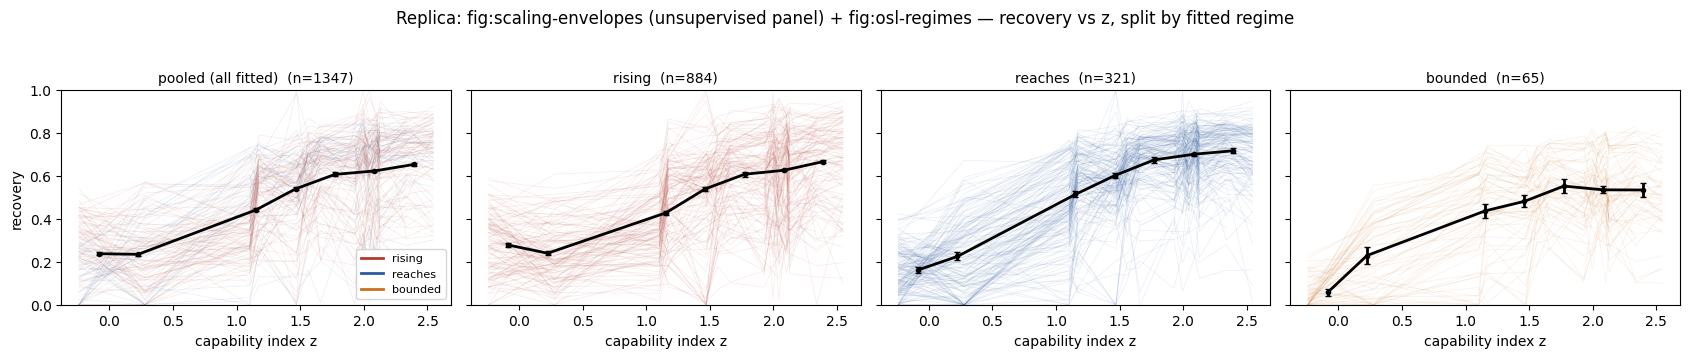

verdict counts (paper: rising 884 / reaches 321 / bounded 65 / 117 excluded): {'RISING': 884, 'REACHES': 321, 'NOISY': 77, 'BOUNDED': 65}


In [6]:
# B.1a — fig:osl-regimes (+ the pooled unsupervised envelope of fig:scaling-envelopes).
# Data: data/2026-07-07-osl-multi/curves_*.json — per-metric recovery vs capability index z,
# 14 executors / 5 families, fitted verdict per metric (RISING / REACHES / BOUNDED).
VCOL = {"RISING": "#b03a2e", "REACHES": "#2c5aa0", "BOUNDED": "#ca6f1e"}
CURVES = []                       # (verdict, dom, name, z, y)
for f in sorted(glob.glob("data/2026-07-07-osl-multi/curves_*.json")):
    dom = os.path.basename(f)[7:-5]
    for name, v in json.load(open(f)).items():
        if v.get("kind") != "bank":
            continue
        z, y = v.get("z"), v.get("y")
        if z and y and len(z) == len(y) and len(z) >= 3:
            CURVES.append((v.get("verdict"), dom, name, z, y))

def binned_mean(rows, B=9):
    zs = [a for _, _, _, z, _ in rows for a in z]
    lo, hi = min(zs), max(zs)
    edges = np.linspace(lo, hi, B + 1)
    out = []
    for i in range(B):
        vals = [min(1, max(0, b)) for _, _, _, z, y in rows
                for a, b in zip(z, y) if edges[i] <= a < edges[i + 1] + (1e-9 if i == B - 1 else 0)]
        if len(vals) >= 20:
            out.append(((edges[i] + edges[i + 1]) / 2, np.mean(vals),
                        1.96 * np.std(vals) / np.sqrt(len(vals))))
    return out

fig, axes = plt.subplots(1, 4, figsize=(17, 3.4), sharey=True)
panels = [("pooled (all fitted)", None)] + [(k.lower(), k) for k in ("RISING", "REACHES", "BOUNDED")]
for ax, (title, vd) in zip(axes, panels):
    rows = [r for r in CURVES if vd is None or r[0] == vd]
    step = max(1, len(rows) // 120)
    for verd, _, _, z, y in rows[::step]:
        ax.plot(z, np.clip(y, 0, 1), color=VCOL.get(verd, "0.6"), alpha=.10, lw=.5)
    bm = binned_mean(rows)
    ax.errorbar([b[0] for b in bm], [b[1] for b in bm], yerr=[b[2] for b in bm],
                color="k", lw=2, marker="o", ms=3, capsize=2)
    ax.set_title(f"{title}  (n={len({(r[1], r[2]) for r in rows})})", fontsize=10)
    ax.set_xlabel("capability index z"); ax.set_ylim(0, 1)
axes[0].set_ylabel("recovery")
from matplotlib.lines import Line2D
axes[0].legend(handles=[Line2D([], [], color=c, lw=2, label=k.lower()) for k, c in VCOL.items()],
               fontsize=8, loc="lower right")
plt.suptitle("Replica: fig:scaling-envelopes (unsupervised panel) + fig:osl-regimes — recovery vs z, split by fitted regime", y=1.04)
plt.tight_layout(); plt.show()
from collections import Counter
print("verdict counts (paper: rising 884 / reaches 321 / bounded 65 / 117 excluded):",
      dict(Counter(r[0] for r in CURVES)))

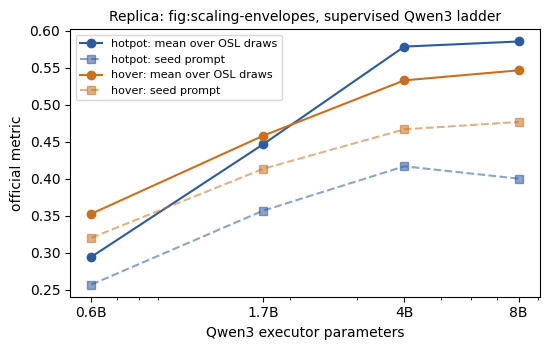

In [7]:
# B.1b — fig:scaling-envelopes (supervised panel): Qwen3 ladder on hotpot + hover.
# Data: datasets/prompt-optimality-test/runs/osl_<bench>_<model>.json (init = seed-prompt
# score; draws = optimized-prompt draws). Same filter as gen_fig_scaling.py (>=20 draws).
import statistics as st
PAR = {"Qwen3-0.6B": 0.6, "Qwen3-1.7B": 1.7, "Qwen3-4B": 4.0, "Qwen3-8B": 8.0}
BC = {"hotpot": "#2c5aa0", "hover": "#ca6f1e"}
pts = {}
for f in sorted(glob.glob("../datasets/prompt-optimality-test/runs/osl_*.json")):
    d = json.load(open(f))
    b, mn = d.get("bench"), d.get("model")
    if b not in BC or mn not in PAR:
        continue
    dr = [x["score"] for x in (d.get("draws") or []) if x.get("score") is not None]
    if d.get("init") is None or len(dr) < 20:
        continue
    pts.setdefault(b, []).append((PAR[mn], d["init"], st.mean(dr)))
fig, ax = plt.subplots(figsize=(5.6, 3.6))
for b, rows in sorted(pts.items()):
    rows.sort()
    ax.plot([r[0] for r in rows], [r[2] for r in rows], "-o", color=BC[b], label=f"{b}: mean over OSL draws")
    ax.plot([r[0] for r in rows], [r[1] for r in rows], "--s", color=BC[b], alpha=.55, label=f"{b}: seed prompt")
ax.set_xscale("log"); ax.set_xticks([0.6, 1.7, 4, 8]); ax.set_xticklabels(["0.6B", "1.7B", "4B", "8B"])
ax.set_xlabel("Qwen3 executor parameters"); ax.set_ylabel("official metric")
ax.set_title("Replica: fig:scaling-envelopes, supervised Qwen3 ladder", fontsize=10)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

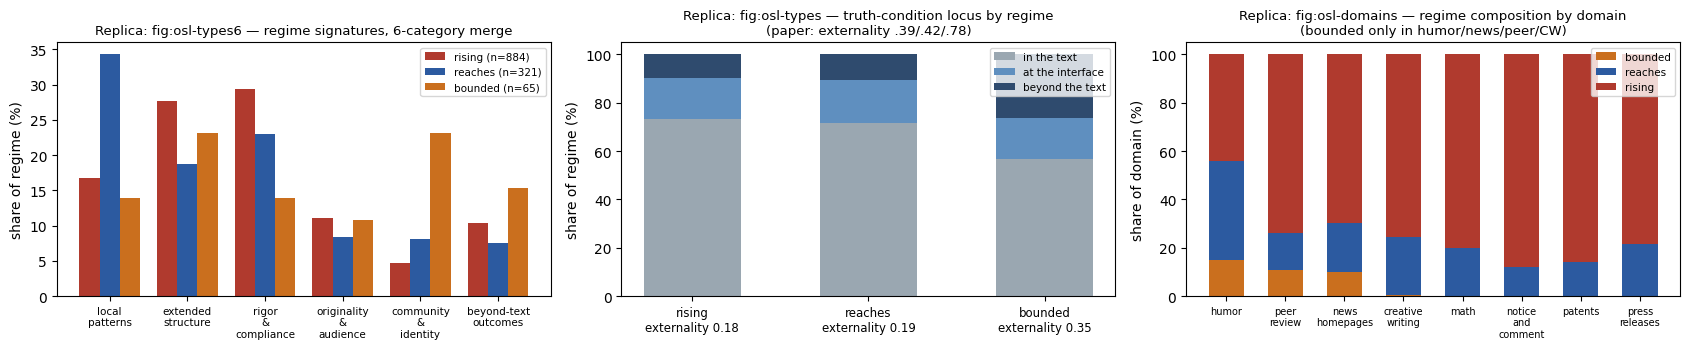

In [8]:
# B.1c — fig:osl-types6 (nested 12->6 merge), fig:osl-types coarse axis, fig:osl-domains.
# Labels: outputs/analyses/osl_metric_types_20260728.json (labels = 9-type pass 1, kappa .75;
# labels_12type = the 12-category codebook; key = per-O-id verdict + domain).
T = json.load(open("../outputs/analyses/osl_metric_types_20260728.json"))
KEY = T["key"]
L12 = {i: (v["label"] if isinstance(v, dict) else v) for i, v in T["labels_12type"].items()}
L9 = {i: (v["label"] if isinstance(v, dict) else v) for i, v in T["labels"].items()}
M6 = {"COMPACT_DEVICE": "local patterns", "EXTENDED_STRUCTURE": "extended structure",
      "SURFACE_CHECK": "rigor & compliance", "ETHICS_HARM": "rigor & compliance",
      "VERIFICATION_SOURCING": "rigor & compliance", "LOGICAL_RIGOR": "rigor & compliance",
      "ORIGINALITY_NOVELTY": "originality & audience", "AUDIENCE_FIT": "originality & audience",
      "COMMUNITY_STANCE": "community & identity", "IDENTITY_PERSONA": "community & identity",
      "ECOSYSTEM_ARTIFACTS": "beyond-text outcomes", "RECEPTION_OUTCOME": "beyond-text outcomes"}
CATS6 = list(dict.fromkeys(M6[k] for k in M6))
REG = ["RISING", "REACHES", "BOUNDED"]
RCOL = {"RISING": "#b03a2e", "REACHES": "#2c5aa0", "BOUNDED": "#ca6f1e"}
AX9 = {"MECHANICAL_CHECK": 0, "CRAFT_OPERATION": 0, "EVIDENCE_RIGOR": 0, "HOLISTIC_TASTE": 0,
       "AUDIENCE_FIT": 1, "COMMUNITY_TRANSFORM": 1,
       "IDENTITY_PERSONA": 2, "EXTERNAL_BUNDLE": 2, "RECEPTION_OUTCOME": 2}

fig, axes = plt.subplots(1, 3, figsize=(17, 3.6))
# (1) 6-category signatures per regime
n_reg = {r: sum(1 for i in L12 if KEY[i]["verdict"] == r) for r in REG}
w = 0.26
for j, r in enumerate(REG):
    shares = [100 * sum(1 for i in L12 if KEY[i]["verdict"] == r and M6[L12[i]] == c) / n_reg[r]
              for c in CATS6]
    axes[0].bar(np.arange(len(CATS6)) + (j - 1) * w, shares, w, color=RCOL[r],
                label=f"{r.lower()} (n={n_reg[r]})")
axes[0].set_xticks(range(len(CATS6)))
axes[0].set_xticklabels([c.replace(" & ", " &\n").replace(" ", "\n", 1) for c in CATS6], fontsize=7.5)
axes[0].set_ylabel("share of regime (%)"); axes[0].legend(fontsize=7.5)
axes[0].set_title("Replica: fig:osl-types6 — regime signatures, 6-category merge", fontsize=9.5)
# (2) coarse axis: where do the truth conditions live (9-type pass-1 labels)
AXN = ["in the text", "at the interface", "beyond the text"]
bot = np.zeros(len(REG))
ACOL = ["#9aa7b1", "#5f8fbf", "#2f4b6e"]
for a in (0, 1, 2):
    shares = [100 * sum(1 for i in L9 if KEY[i]["verdict"] == r and AX9[L9[i]] == a) / n_reg[r]
              for r in REG]
    axes[1].bar(range(len(REG)), shares, 0.55, bottom=bot, color=ACOL[a], label=AXN[a])
    bot += np.array(shares)
ext = {r: np.mean([AX9[L9[i]] / 2 for i in L9 if KEY[i]["verdict"] == r]) for r in REG}
axes[1].set_xticks(range(len(REG)))
axes[1].set_xticklabels([f"{r.lower()}\nexternality {ext[r]:.2f}" for r in REG], fontsize=8.5)
axes[1].set_ylabel("share of regime (%)"); axes[1].legend(fontsize=7.5)
axes[1].set_title("Replica: fig:osl-types — truth-condition locus by regime\n(paper: externality .39/.42/.78)", fontsize=9.5)
# (3) regime composition by domain
from collections import Counter
dom_reg = {}
for i, k in KEY.items():
    dom_reg.setdefault(k["dom"], Counter())[k["verdict"]] += 1
doms = sorted(dom_reg, key=lambda d: -dom_reg[d]["BOUNDED"] / max(1, sum(dom_reg[d].values())))
bot = np.zeros(len(doms))
for r in ("BOUNDED", "REACHES", "RISING"):
    shares = [100 * dom_reg[d][r] / sum(dom_reg[d].values()) for d in doms]
    axes[2].bar(range(len(doms)), shares, 0.6, bottom=bot, color=RCOL[r], label=r.lower())
    bot += np.array(shares)
axes[2].set_xticks(range(len(doms)))
axes[2].set_xticklabels([d.replace("_", "\n") for d in doms], fontsize=7)
axes[2].set_ylabel("share of domain (%)"); axes[2].legend(fontsize=7.5)
axes[2].set_title("Replica: fig:osl-domains — regime composition by domain\n(bounded only in humor/news/peer/CW)", fontsize=9.5)
plt.tight_layout(); plt.show()

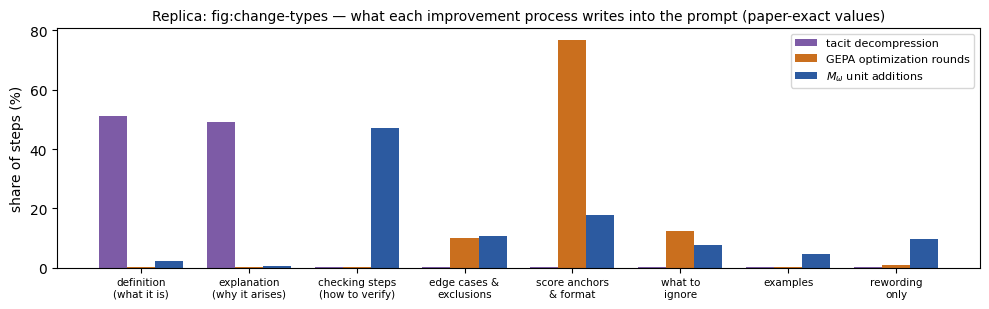

In [9]:
# B.1d — fig:change-types replica. The certified labels lived in a session scratchpad;
# the AUTO-GENERATED TikZ (figs/gen_change_types.tex, HB174-certified) carries the exact
# bar heights, so we parse the paper-exact values back out of it (share = height/3.10*100).
import re
TEX = open("../latex/paper-2__articulation-upper-bounds/figs/gen_change_types.tex").read()
FILLS = {"violet!25": "tacit decompression", "orange!35": "GEPA optimization rounds",
         "blue!30": "$M_\\omega$ unit additions"}
bars = re.findall(r"\\fill\[(violet!25|orange!35|blue!30)[^\]]*\] \(([\d.]+),0\) rectangle \(([\d.]+),([\d.]+)\);", TEX)
CATS = ["definition\n(what it is)", "explanation\n(why it arises)", "checking steps\n(how to verify)",
        "edge cases &\nexclusions", "score anchors\n& format", "what to\nignore", "examples", "rewording\nonly"]
series = {v: [] for v in FILLS.values()}
for fill, x0, x1, h in bars:
    series[FILLS[fill]].append(float(h) / 3.1 * 100)
fig, ax = plt.subplots(figsize=(10, 3.2))
w = 0.26
SCOL = {"tacit decompression": "#7d5ba6", "GEPA optimization rounds": "#ca6f1e",
        "$M_\\omega$ unit additions": "#2c5aa0"}
for j, (nm, vals) in enumerate(series.items()):
    ax.bar(np.arange(len(CATS)) + (j - 1) * w, vals[:len(CATS)], w, color=SCOL[nm], label=nm)
ax.set_xticks(range(len(CATS))); ax.set_xticklabels(CATS, fontsize=7.5)
ax.set_ylabel("share of steps (%)"); ax.legend(fontsize=8)
ax.set_title("Replica: fig:change-types — what each improvement process writes into the prompt (paper-exact values)", fontsize=10)
plt.tight_layout(); plt.show()

In [10]:
# B.1e — Table 1 (tab:main-results) and Table 2 (tab:mi-silver) as printed, with live status.
t1 = pd.DataFrame([
    ["HotpotQA", .411, .400, .439, .646, "+.235***"],
    ["HoVer", .471, .517, None, .557, "+.086*** (re-mint at 10,110-call parity: +.066* [.040,.093])"],
    ["LiveBench", .699, .688, .677, .705, "+.006 n.s."],
    ["IFBench", .403, .411, .383, .443, "+.040**"],
    ["AIME", .385, .373, .323, .392, "+.007 n.s."],
    ["PUPA", .883, None, None, .882, "-.001 — RE-MINT IN FLIGHT on sk1 2026-08-11 (fresh same-session: GEPA .9062 / MIPROv2 .8831 / Merge .8442; M_omega pending)"],
], columns=["benchmark", "GEPA", "GEPA+Merge", "MIPROv2", "eps-cert (M_omega)", "Delta vs GEPA"])
display(t1)
t2 = pd.DataFrame([
    ["peer-review", .68], ["code-review", .62], ["creative-writing", .61],
    ["math", .56], ["press-releases", .50], ["humor", .45],
], columns=["task", "corrected rho (MI vs judge-vs-silver AUC)"])
display(t2)
print("Table 2 design (held result — the paper's validity anchor): WITHIN-metric across its own prompt")
print("forms; Spearman, Fisher-z pooled, attenuation-corrected; code-review confirmed out-of-sample")
print("against a preregistered stratum; press-releases observed interval includes zero (disclosed).")

,benchmark,GEPA,GEPA+Merge,MIPROv2,eps-cert (M_omega),Delta vs GEPA
0,HotpotQA,0.411,0.400,0.439,0.646,+.235***
1,HoVer,0.471,0.517,NaN,0.557,"+.086*** (re-mint at 10,110-call parity: +.066..."
2,LiveBench,0.699,0.688,0.677,0.705,+.006 n.s.
3,IFBench,0.403,0.411,0.383,0.443,+.040**
4,AIME,0.385,0.373,0.323,0.392,+.007 n.s.
5,PUPA,0.883,NaN,NaN,0.882,-.001 — RE-MINT IN FLIGHT on sk1 2026-08-11 (f...


,task,corrected rho (MI vs judge-vs-silver AUC)
0,peer-review,0.68
1,code-review,0.62
2,creative-writing,0.61
3,math,0.56
4,press-releases,0.50
5,humor,0.45


Table 2 design (held result — the paper's validity anchor): WITHIN-metric across its own prompt
forms; Spearman, Fisher-z pooled, attenuation-corrected; code-review confirmed out-of-sample
against a preregistered stratum; press-releases observed interval includes zero (disclosed).


## B.2 The new OSL instruments (2026-08-05 → 08-11), one exhibit each

These are the panels the re-organized §4 draws on. Everything below the first exhibit conditions the §4 story on **listener family, reference reliability, and articulation channel** — the three variables the current draft's single-curve presentation pools over.

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_13484/4046728934.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data, labels=FAMS, showfliers=False, patch_artist=True)


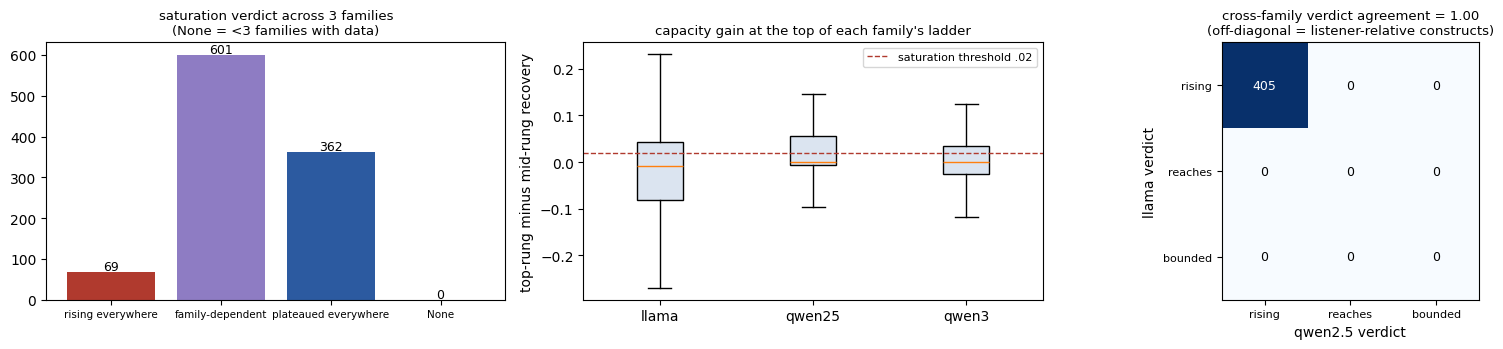

INSIGHT: the regime label is a property of (construct, listener family), not the construct.


In [11]:
# B.2a — three-family saturation census (family_verdict_join_v1). satgroup: a construct is
# 'rising' if top-minus-mid > .02 in ALL families with data (>=3), 'plateaued' if <= .02 in
# all, else 'family-dependent'.
FJ = json.load(open(f"{D}/analyses/family_verdict_join_v1.json"))["full_rows"]
def satgroup(r, t=.02):
    tm = [v for v in r["top_minus_mid"].values() if v is not None]
    if len(tm) < 3: return None
    if all(v > t for v in tm): return "rising everywhere"
    if all(v <= t for v in tm): return "plateaued everywhere"
    return "family-dependent"
from collections import Counter
sg = Counter(satgroup(r) for r in FJ)
fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))
order = ["rising everywhere", "family-dependent", "plateaued everywhere", None]
axes[0].bar([str(o) for o in order], [sg[o] for o in order],
            color=["#b03a2e", "#8e7cc3", "#2c5aa0", "0.7"])
for i, o in enumerate(order):
    axes[0].text(i, sg[o] + 5, str(sg[o]), ha="center", fontsize=9)
axes[0].set_title("saturation verdict across 3 families\n(None = <3 families with data)", fontsize=9.5)
axes[0].tick_params(axis="x", labelsize=7.5)
# per-family top-minus-mid distributions
FAMS = ["llama", "qwen25", "qwen3"]
data = [[r["top_minus_mid"][f] for r in FJ if r["top_minus_mid"].get(f) is not None] for f in FAMS]
bp = axes[1].boxplot(data, labels=FAMS, showfliers=False, patch_artist=True)
for p in bp["boxes"]: p.set_facecolor("#dbe4f0")
axes[1].axhline(0.02, color="#b03a2e", ls="--", lw=1, label="saturation threshold .02")
axes[1].set_ylabel("top-rung minus mid-rung recovery"); axes[1].legend(fontsize=8)
axes[1].set_title("capacity gain at the top of each family's ladder", fontsize=9.5)
# verdict agreement heatmap llama x qwen25
VN = ["RISING", "REACHES", "BOUNDED"]
M = np.zeros((3, 3))
for r in FJ:
    a, b = r["verdict3"].get("llama"), r["verdict3"].get("qwen25")
    if a in VN and b in VN:
        M[VN.index(a), VN.index(b)] += 1
im = axes[2].imshow(M, cmap="Blues")
for i in range(3):
    for j in range(3):
        axes[2].text(j, i, int(M[i, j]), ha="center", va="center",
                     color="w" if M[i, j] > M.max() / 2 else "k", fontsize=9)
axes[2].set_xticks(range(3)); axes[2].set_xticklabels([v.lower() for v in VN], fontsize=8)
axes[2].set_yticks(range(3)); axes[2].set_yticklabels([v.lower() for v in VN], fontsize=8)
axes[2].set_xlabel("qwen2.5 verdict"); axes[2].set_ylabel("llama verdict")
agree = np.trace(M) / M.sum()
axes[2].set_title(f"cross-family verdict agreement = {agree:.2f}\n(off-diagonal = listener-relative constructs)", fontsize=9.5)
plt.tight_layout(); plt.show()
print("INSIGHT: the regime label is a property of (construct, listener family), not the construct.")

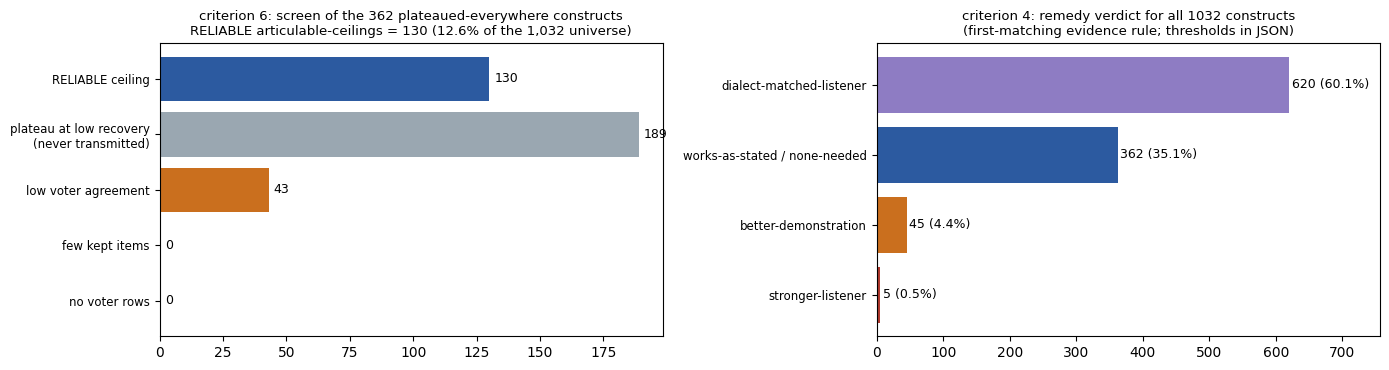

INSIGHT: 'plateaued' decomposes — only 12.6% of the universe is a certified ceiling;
and the modal remedy is a dialect-matched listener, not more capability.


In [12]:
# B.2b — which plateaus are real (criterion-6 reliability filter) + the remedy table
# (criterion 4). Thresholds: voter agreement >= .70, kept items >= 150, top non-voter
# recovery >= .65.
RF = json.load(open("../outputs/analyses/reliability_filter_v1/reliability_filter_v1.json"))["rows"]
VT = json.load(open("../outputs/analyses/verdict_table_v1/verdict_table_v1.json"))["rows"]
from collections import Counter
def fail_mode(r):
    if r["status"] != "ok": return "no voter rows"
    if r["reliable_plateau"]: return "RELIABLE ceiling"
    if r["agreement"] < .70: return "low voter agreement"
    if r["kept_n"] < 150: return "few kept items"
    return "plateau at low recovery\n(never transmitted)"
fm = Counter(fail_mode(r) for r in RF)
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
keys = ["RELIABLE ceiling", "plateau at low recovery\n(never transmitted)",
        "low voter agreement", "few kept items", "no voter rows"]
cols = ["#2c5aa0", "#9aa7b1", "#ca6f1e", "#caa46f", "0.75"]
axes[0].barh(range(len(keys)), [fm.get(k, 0) for k in keys], color=cols)
for i, k in enumerate(keys):
    axes[0].text(fm.get(k, 0) + 2, i, str(fm.get(k, 0)), va="center", fontsize=9)
axes[0].set_yticks(range(len(keys))); axes[0].set_yticklabels(keys, fontsize=8.5)
axes[0].invert_yaxis()
axes[0].set_title(f"criterion 6: screen of the {len(RF)} plateaued-everywhere constructs\n"
                  f"RELIABLE articulable-ceilings = {fm.get('RELIABLE ceiling',0)} "
                  f"({100*fm.get('RELIABLE ceiling',0)/1032:.1f}% of the 1,032 universe)", fontsize=9.5)
rem = Counter(r["remedy"] for r in VT)
labels, vals = zip(*rem.most_common())
axes[1].barh(range(len(labels)), vals, color=["#8e7cc3", "#2c5aa0", "#ca6f1e", "#b03a2e", "0.6", "0.8"][:len(labels)])
for i, v in enumerate(vals):
    axes[1].text(v + 4, i, f"{v} ({100*v/len(VT):.1f}%)", va="center", fontsize=9)
axes[1].set_yticks(range(len(labels))); axes[1].set_yticklabels(labels, fontsize=8.5)
axes[1].invert_yaxis(); axes[1].set_xlim(0, max(vals) * 1.22)
axes[1].set_title(f"criterion 4: remedy verdict for all {len(VT)} constructs\n(first-matching evidence rule; thresholds in JSON)", fontsize=9.5)
plt.tight_layout(); plt.show()
print("INSIGHT: 'plateaued' decomposes — only 12.6% of the universe is a certified ceiling;")
print("and the modal remedy is a dialect-matched listener, not more capability.")

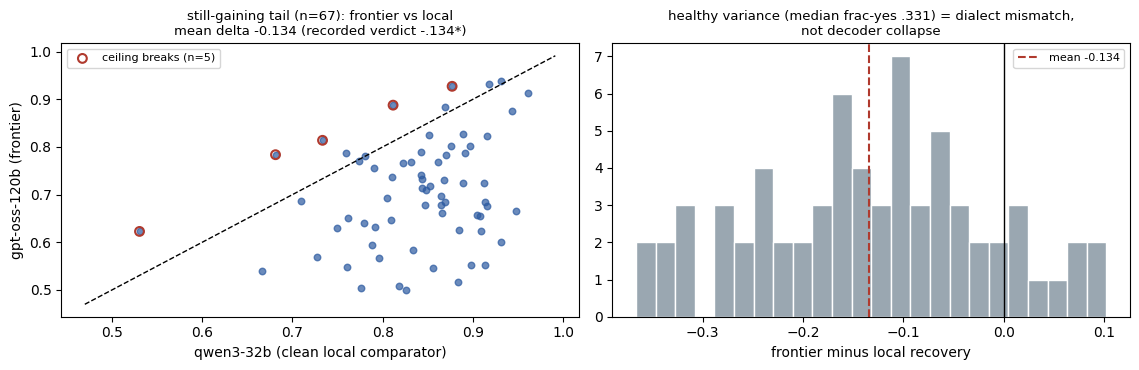

INSIGHT: under the LOCAL-dialect reference, raw frontier capability does not uncap the tail;
the asymptote of the rising regime remains unidentified — a listener-dialect bound, not a z bound.


In [13]:
# B.2c — the frontier does not de-censor the still-gaining tail (task 2b). Each point =
# one of the 69 tail constructs; x = best clean local comparator (qwen3-32b, non-voter),
# y = gpt-oss-120b (frontier), both against the local 2-voter reference.
DH = {r["b"]: r for r in json.load(open(f"{D}/analyses/decensor_harvest_v1.json"))}
TAIL = [tuple(r) if isinstance(r, list) else (r["task"], r["name"])
        for r in json.load(open(f"{D}/flips/decensor_tail_v1.json"))]
xs, ys = [], []
for t, n in TAIL:
    r = DH.get(n)
    if r and r.get("qwen3-32b") is not None and r.get("gptoss") is not None:
        xs.append(r["qwen3-32b"]); ys.append(r["gptoss"])
xs, ys = np.array(xs), np.array(ys)
d = ys - xs
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
axes[0].scatter(xs, ys, s=22, alpha=.7, color="#2c5aa0")
lim = [min(xs.min(), ys.min()) - .03, max(xs.max(), ys.max()) + .03]
axes[0].plot(lim, lim, "k--", lw=1)
brk = d >= .05
axes[0].scatter(xs[brk], ys[brk], s=40, facecolors="none", edgecolors="#b03a2e", lw=1.5,
                label=f"ceiling breaks (n={brk.sum()})")
axes[0].set_xlabel("qwen3-32b (clean local comparator)"); axes[0].set_ylabel("gpt-oss-120b (frontier)")
axes[0].legend(fontsize=8)
axes[0].set_title(f"still-gaining tail (n={len(xs)}): frontier vs local\nmean delta {d.mean():+.3f} (recorded verdict -.134*)", fontsize=9.5)
axes[1].hist(d, bins=24, color="#9aa7b1", edgecolor="w")
axes[1].axvline(0, color="k", lw=1); axes[1].axvline(d.mean(), color="#b03a2e", lw=1.5, ls="--",
                                                     label=f"mean {d.mean():+.3f}")
axes[1].set_xlabel("frontier minus local recovery"); axes[1].legend(fontsize=8)
axes[1].set_title("healthy variance (median frac-yes .331) = dialect mismatch,\nnot decoder collapse", fontsize=9.5)
plt.tight_layout(); plt.show()
print("INSIGHT: under the LOCAL-dialect reference, raw frontier capability does not uncap the tail;")
print("the asymptote of the rising regime remains unidentified — a listener-dialect bound, not a z bound.")

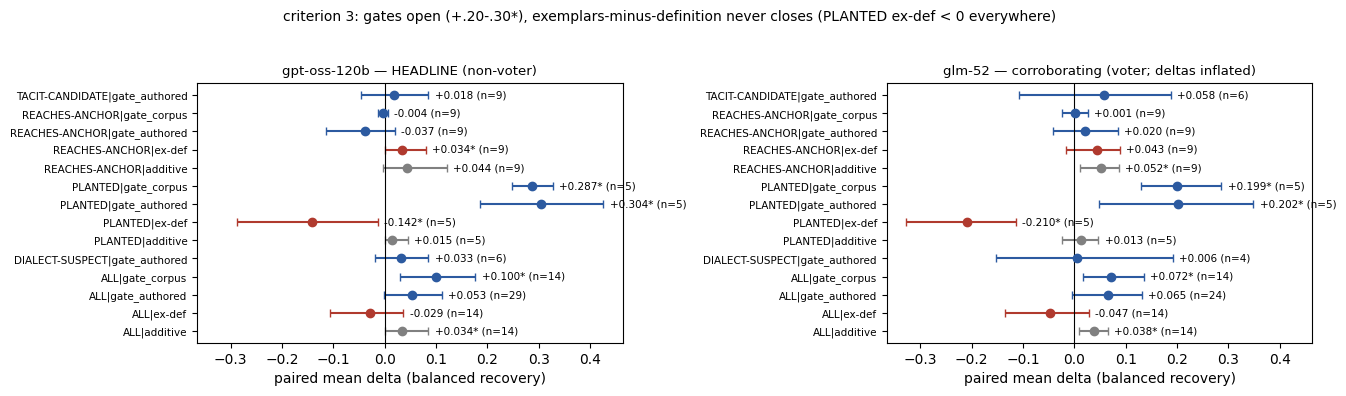

THE ANSWER (as certified): the gate opens; the gap never closes — demonstration succeeds where
restatement fails, and this survives the strongest receiver measured. Math leg corroborates (ex-def -.093*).


In [14]:
# B.2d — the limit question (criterion 3): planted tacit constructs at the frontier.
# Headline receiver = gpt-oss-120b (NON-voter, clean); GLM-5.2 corroborates but is a
# reference voter (circularity inflates its deltas — disclosed).
FL = json.load(open(f"{D}/analyses/frontier_limit_humor_v2.json"))["receivers"]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 3.8), sharex=True)
for ax, rcv in zip(axes, ["gpt-oss-120b", "glm-52"]):
    con = FL[rcv]["contrasts"]
    keys = sorted(con.keys())
    ys = np.arange(len(keys))
    for i, k in enumerate(keys):
        c = con[k]
        col = "#b03a2e" if "ex-def" in k else ("#2c5aa0" if "gate" in k else "0.5")
        ax.errorbar(c["mean"], i, xerr=[[c["mean"] - c["ci"][0]], [c["ci"][1] - c["mean"]]],
                    fmt="o", color=col, capsize=3)
        star = "*" if c["ci"][0] > 0 or c["ci"][1] < 0 else ""
        ax.text(c["ci"][1] + .012, i, f"{c['mean']:+.3f}{star} (n={c['n']})", va="center", fontsize=7.5)
    ax.axvline(0, color="k", lw=.8)
    ax.set_yticks(ys); ax.set_yticklabels(keys, fontsize=7.5)
    ax.set_title(rcv + (" — HEADLINE (non-voter)" if "oss" in rcv else " — corroborating (voter; deltas inflated)"), fontsize=9.5)
    ax.set_xlabel("paired mean delta (balanced recovery)")
plt.suptitle("criterion 3: gates open (+.20-.30*), exemplars-minus-definition never closes (PLANTED ex-def < 0 everywhere)", y=1.03, fontsize=10)
plt.tight_layout(); plt.show()
print("THE ANSWER (as certified): the gate opens; the gap never closes — demonstration succeeds where")
print("restatement fails, and this survives the strongest receiver measured. Math leg corroborates (ex-def -.093*).")

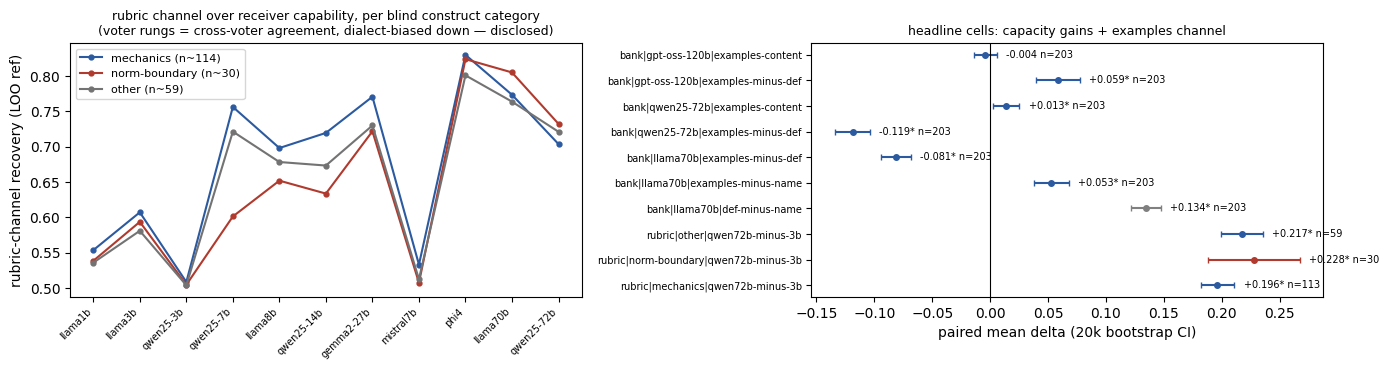

DISCLOSED: explanation/dossier channels: slate-only (41 bases)
DISCLOSED: thinking channel: slate x qwen3 rungs only
DISCLOSED: 'units' channel: no construct-side scored instrument; 4.1 unit decomposition is definitional (codability), not a channel score
DISCLOSED: name channel at bank: llama70b holdout only


In [15]:
# B.2e — channel x capability at bank scale (criterion 2, exhibit v2, LOO references).
CH = json.load(open("../outputs/analyses/channel_scale_v2/channel_scale_v2.json"))
LADDER_B = ["llama1b", "llama3b", "qwen25-3b", "qwen25-7b", "llama8b", "qwen25-14b",
            "gemma2-27b", "mistral7b", "phi4", "llama70b", "qwen25-72b"]
CCOL = {"norm-boundary": "#b03a2e", "mechanics": "#2c5aa0", "other": "0.45"}
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
for g, curve in CH["bank_rubric_curves"]["category"].items():
    xs = [i for i, ex in enumerate(LADDER_B) if curve.get(ex)]
    ys = [curve[ex]["mean"] for ex in LADDER_B if curve.get(ex)]
    axes[0].plot(xs, ys, "-o", ms=3.5, color=CCOL.get(g, "0.7"), label=f"{g} (n~{max(curve[ex]['n'] for ex in LADDER_B if curve.get(ex))})")
axes[0].set_xticks(range(len(LADDER_B)))
axes[0].set_xticklabels(LADDER_B, rotation=45, ha="right", fontsize=7)
axes[0].set_ylabel("rubric-channel recovery (LOO ref)")
axes[0].legend(fontsize=8)
axes[0].set_title("rubric channel over receiver capability, per blind construct category\n(voter rungs = cross-voter agreement, dialect-biased down — disclosed)", fontsize=9)
cells_ = {k: v for k, v in CH["headline_cells"].items()}
keys = list(cells_)
ys = np.arange(len(keys))
for i, k in enumerate(keys):
    c = cells_[k]
    star = c["ci"][0] > 0 or c["ci"][1] < 0
    col = "#b03a2e" if "norm-boundary" in k else ("#2c5aa0" if "examples" in k or "rubric" in k else "0.5")
    axes[1].errorbar(c["delta"], i, xerr=[[c["delta"] - c["ci"][0]], [c["ci"][1] - c["delta"]]],
                     fmt="o", ms=4, color=col, capsize=2)
    axes[1].text(c["ci"][1] + .008, i, f"{c['delta']:+.3f}{'*' if star else ''} n={c['n']}", va="center", fontsize=7)
axes[1].axvline(0, color="k", lw=.8)
axes[1].set_yticks(ys); axes[1].set_yticklabels(keys, fontsize=7)
axes[1].set_xlabel("paired mean delta (20k bootstrap CI)")
axes[1].set_title("headline cells: capacity gains + examples channel", fontsize=9)
plt.tight_layout(); plt.show()
for note in CH["coverage_disclosures"]:
    print("DISCLOSED:", note)

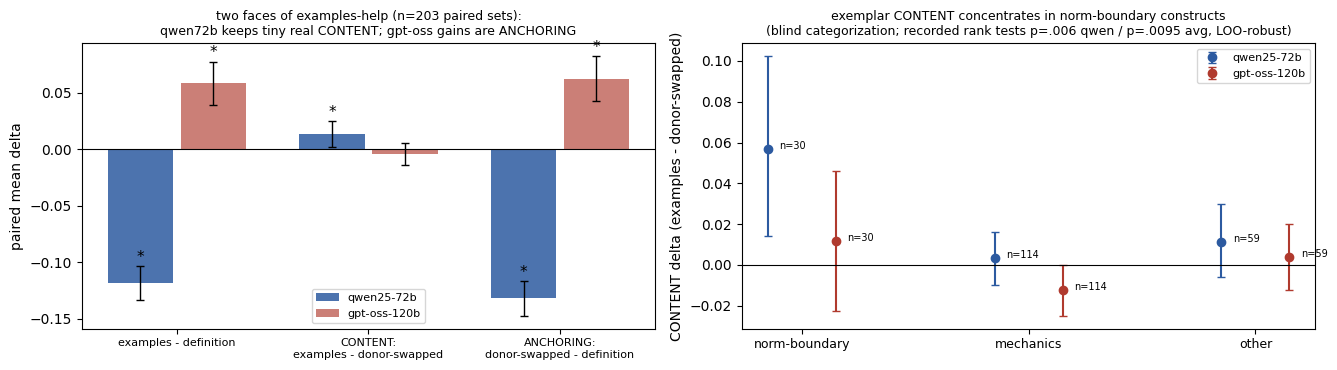

In [16]:
# B.2f — the examples program at bank scale: 222 flip-selected exemplar sets x two
# receivers, donor-swapped (mm) controls; blind construct categories (30 norm-boundary /
# 114 mechanics / 59 other).
LED = json.load(open(f"{D}/analyses/v3sets_ledger_v1.json"))
CAT = json.load(open(f"{D}/analyses/metric_categories_blind_v1.json"))
rng = np.random.default_rng(0)
def ci20(d):
    d = np.asarray(d, float)
    bm = d[rng.integers(0, len(d), size=(20000, len(d)))].mean(1)
    return d.mean(), np.percentile(bm, 2.5), np.percentile(bm, 97.5)
CONTRASTS = [("examples - definition", lambda r: r["functional"] - r["definition"]),
             ("CONTENT: examples - donor-swapped", lambda r: r["functional"] - r["functionalmm"]),
             ("ANCHORING: donor-swapped - definition", lambda r: r["functionalmm"] - r["definition"])]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 3.8))
w = 0.38
for j, rcv in enumerate(["qwen25-72b", "gpt-oss-120b"]):
    rows = LED[rcv]
    for i, (nm, fn) in enumerate(CONTRASTS):
        m, lo, hi = ci20([fn(r) for r in rows])
        star = lo > 0 or hi < 0
        axes[0].bar(i + (j - .5) * w, m, w * .9, color=["#2c5aa0", "#b03a2e"][j],
                    alpha=.85 if j == 0 else .65, label=rcv if i == 0 else None)
        axes[0].errorbar(i + (j - .5) * w, m, yerr=[[m - lo], [hi - m]], color="k", capsize=3, lw=1)
        axes[0].text(i + (j - .5) * w, hi + .004, "*" if star else "", ha="center", fontsize=11)
axes[0].axhline(0, color="k", lw=.8)
axes[0].set_xticks(range(3)); axes[0].set_xticklabels([c[0].replace(": ", ":\n") for c in CONTRASTS], fontsize=8)
axes[0].legend(fontsize=8); axes[0].set_ylabel("paired mean delta")
axes[0].set_title("two faces of examples-help (n=203 paired sets):\nqwen72b keeps tiny real CONTENT; gpt-oss gains are ANCHORING", fontsize=9)
# per-category content at each receiver
cats = ["norm-boundary", "mechanics", "other"]
for j, rcv in enumerate(["qwen25-72b", "gpt-oss-120b"]):
    rows = LED[rcv]
    for i, c in enumerate(cats):
        vals = [r["functional"] - r["functionalmm"] for r in rows if CAT.get(r["b"]) == c]
        if not vals: continue
        m, lo, hi = ci20(vals)
        axes[1].errorbar(i + (j - .5) * .3, m, yerr=[[m - lo], [hi - m]], fmt="o",
                         color=["#2c5aa0", "#b03a2e"][j], capsize=3,
                         label=rcv if i == 0 else None)
        axes[1].text(i + (j - .5) * .3 + .05, m, f"n={len(vals)}", fontsize=7)
axes[1].axhline(0, color="k", lw=.8)
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(cats, fontsize=9)
axes[1].legend(fontsize=8); axes[1].set_ylabel("CONTENT delta (examples - donor-swapped)")
axes[1].set_title("exemplar CONTENT concentrates in norm-boundary constructs\n(blind categorization; recorded rank tests p=.006 qwen / p=.0095 avg, LOO-robust)", fontsize=9)
plt.tight_layout(); plt.show()

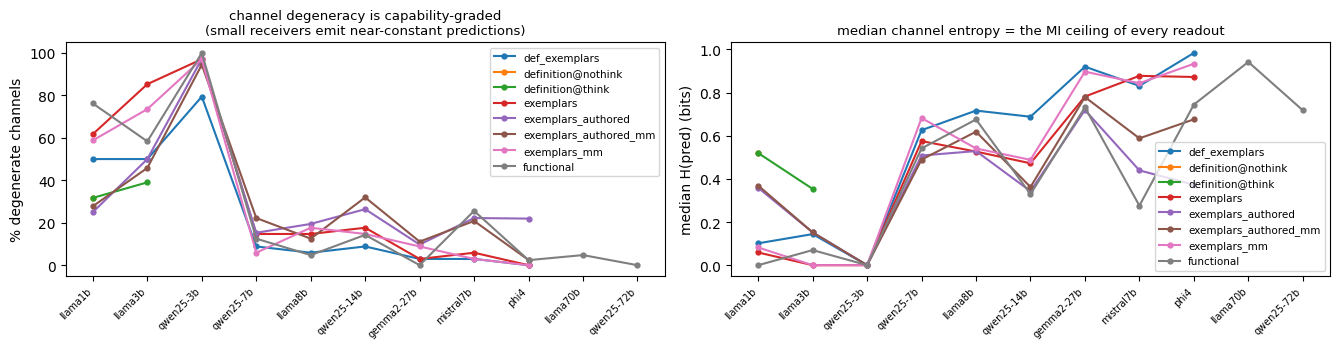

INSIGHT: ladder floors at small z are CHANNEL COLLAPSE, not construct absence — every low-z
recovery number in this notebook is read against this census.


In [17]:
# B.2g — the MI upper-bound census: every decoder channel is bounded by H(pred); a
# constant prediction row has ZERO mutual information no matter what the construct is.
MI = json.load(open(f"{D}/analyses/mi_upper_census_v2.json"))["rows"]
mdf = pd.DataFrame(MI)
LADDER_B = ["llama1b", "llama3b", "qwen25-3b", "qwen25-7b", "llama8b", "qwen25-14b",
            "gemma2-27b", "mistral7b", "phi4", "llama70b", "qwen25-72b", "gpt-oss-120b"]
sub = mdf[mdf["ex"].isin(LADDER_B)]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 3.6))
for arm, g in sub.groupby("arm"):
    stats = g.groupby("ex").agg(deg=("degenerate", "mean"), H=("H_pred", "median"))
    stats = stats.reindex([e for e in LADDER_B if e in stats.index])
    axes[0].plot(range(len(stats)), 100 * stats["deg"], "-o", ms=3.5, label=arm)
    axes[1].plot(range(len(stats)), stats["H"], "-o", ms=3.5, label=arm)
    axes[0].set_xticks(range(len(stats))); axes[0].set_xticklabels(stats.index, rotation=45, ha="right", fontsize=7)
    axes[1].set_xticks(range(len(stats))); axes[1].set_xticklabels(stats.index, rotation=45, ha="right", fontsize=7)
axes[0].set_ylabel("% degenerate channels"); axes[0].legend(fontsize=7.5)
axes[0].set_title("channel degeneracy is capability-graded\n(small receivers emit near-constant predictions)", fontsize=9.5)
axes[1].set_ylabel("median H(pred) (bits)"); axes[1].legend(fontsize=7.5)
axes[1].set_title("median channel entropy = the MI ceiling of every readout", fontsize=9.5)
plt.tight_layout(); plt.show()
print("INSIGHT: ladder floors at small z are CHANNEL COLLAPSE, not construct absence — every low-z")
print("recovery number in this notebook is read against this census.")

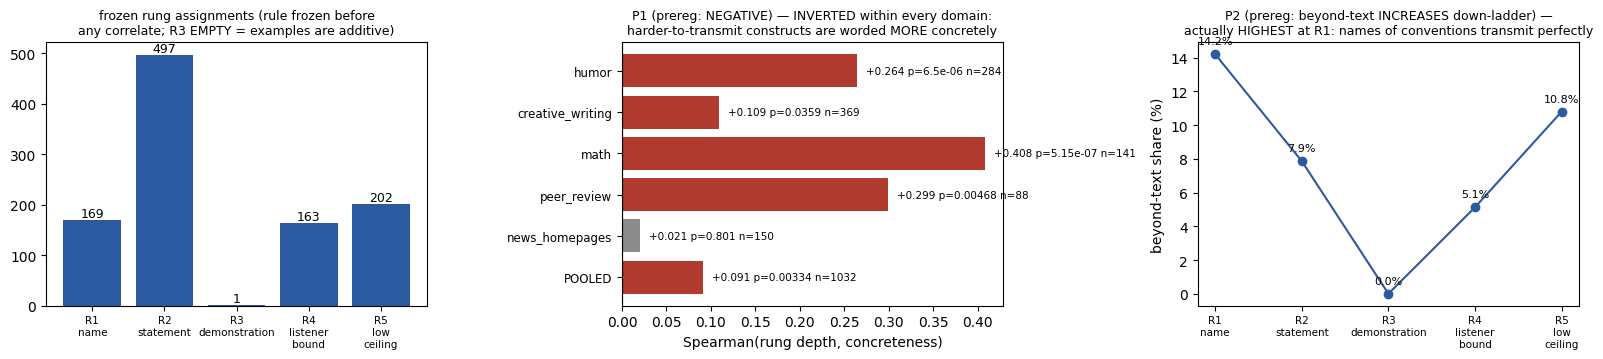

PREREG LANDING (frozen zone 3): the operational ladder does not reduce to lexical abstractness.
NOTE: P1 forest is a re-implementation of the audited instrument; committed reference values
(2026-08-11) are humor +.264 / math +.397 / peer +.287 / CW +.114 / news +.010, pooled +.092.


In [18]:
# B.2h — the operational ladder (criterion 5): frozen rung rule, then the preregistered
# abstractness predictions P1-P2. P1 recompute uses the AUDITED instrument (expanded
# function-word list + suffix lemmatizer + Brysbaert norms). Reference values from the
# 2026-08-11 audited run: within-task Spearman humor +.264*** / math +.397*** /
# peer +.287** / CW +.114* / news +.010 n.s.; pooled +.092.
import csv, re
from scipy import stats as sps
LAD = json.load(open("../outputs/analyses/ladder_p123_v1/ladder_p123_v1.json"))["rows"]
RUNGS = ["R1-name", "R2-statement", "R3-demonstration", "R4-listener-bound", "R5-low-ceiling"]
CONC = {}
for rec in csv.DictReader(open(f"{D}/analyses/brysbaert_concreteness.csv"), delimiter="\t"):
    try: CONC[rec["Word"].lower()] = float(rec["Conc.M"])
    except (ValueError, KeyError): pass
FUNC = set(('''the a an and or but nor of to in for with on by at from into over under as that this
these those it its they them their there here is are was were be been being am do does did done
have has had having will would shall should can could may might must not no yes if then else when
while which who whom whose what where why how all any some none each every either neither both few
many much more most other another such only own same so than too very just also again further once
about against between through during before after above below up down out off again very'''.split()))
def lemma(w):
    for suf, rep in (("ies", "y"), ("es", ""), ("s", ""), ("ing", ""), ("ing", "e"), ("ed", ""), ("ed", "e")):
        if w.endswith(suf) and len(w) > len(suf) + 2:
            cand = w[:len(w) - len(suf)] + rep
            if cand in CONC: return cand
    return w
DEFS = {}
for t in TASKS:
    for m in json.load(open(f"{D}/code_metrics/defs_{t}.json")):
        DEFS[(t, m["name"])] = m["definition"]
def conc_of(text):
    toks = [w for w in re.findall(r"[a-z]+", text.lower()) if w not in FUNC]
    vals = [CONC[lemma(w)] for w in toks if lemma(w) in CONC]
    return float(np.mean(vals)) if len(vals) >= 5 else None
for r in LAD:
    r["conc2"] = conc_of(r["name"] + " " + DEFS.get((r["task"], r["name"]), ""))
fig, axes = plt.subplots(1, 3, figsize=(16, 3.7))
from collections import Counter
rc = Counter(r["rung"] for r in LAD)
axes[0].bar(range(len(RUNGS)), [rc[g] for g in RUNGS], color="#2c5aa0")
for i, g in enumerate(RUNGS):
    axes[0].text(i, rc[g] + 6, str(rc[g]), ha="center", fontsize=9)
axes[0].set_xticks(range(len(RUNGS)))
axes[0].set_xticklabels([g.replace("-", "\n") for g in RUNGS], fontsize=7.5)
axes[0].set_title("frozen rung assignments (rule frozen before\nany correlate; R3 EMPTY = examples are additive)", fontsize=9)
# P1 within-task forest
rows, labels = [], []
ok = [r for r in LAD if r["conc2"] is not None]
for t in TASKS:
    sub = [r for r in ok if r["task"] == t]
    rho, p = sps.spearmanr([r["rung_idx"] for r in sub], [r["conc2"] for r in sub])
    rows.append((rho, p, len(sub))); labels.append(t)
prho, pp = sps.spearmanr([r["rung_idx"] for r in ok], [r["conc2"] for r in ok])
rows.append((prho, pp, len(ok))); labels.append("POOLED")
for i, ((rho, p, n), lb) in enumerate(zip(rows, labels)):
    col = "#b03a2e" if p < .05 else "0.55"
    axes[1].barh(i, rho, color=col)
    axes[1].text(rho + (.01 if rho >= 0 else -.01), i, f"{rho:+.3f} p={p:.3g} n={n}",
                 va="center", ha="left" if rho >= 0 else "right", fontsize=7.5)
axes[1].axvline(0, color="k", lw=.8)
axes[1].set_yticks(range(len(labels))); axes[1].set_yticklabels(labels, fontsize=8.5)
axes[1].invert_yaxis(); axes[1].set_xlabel("Spearman(rung depth, concreteness)")
axes[1].set_title("P1 (prereg: NEGATIVE) — INVERTED within every domain:\nharder-to-transmit constructs are worded MORE concretely", fontsize=9)
# P2 beyond-text share by rung
sh = []
for g in RUNGS:
    sub = [r for r in LAD if r["rung"] == g and r["axis"] is not None]
    sh.append(100 * np.mean([r["axis"] == 2 for r in sub]) if sub else np.nan)
axes[2].plot(range(len(RUNGS)), sh, "-o", color="#2c5aa0")
for i, v in enumerate(sh):
    if np.isfinite(v): axes[2].text(i, v + .6, f"{v:.1f}%", ha="center", fontsize=8)
axes[2].set_xticks(range(len(RUNGS)))
axes[2].set_xticklabels([g.replace("-", "\n") for g in RUNGS], fontsize=7.5)
axes[2].set_ylabel("beyond-text share (%)")
axes[2].set_title("P2 (prereg: beyond-text INCREASES down-ladder) —\nactually HIGHEST at R1: names of conventions transmit perfectly", fontsize=9)
plt.tight_layout(); plt.show()
print("PREREG LANDING (frozen zone 3): the operational ladder does not reduce to lexical abstractness.")
print("NOTE: P1 forest is a re-implementation of the audited instrument; committed reference values")
print("(2026-08-11) are humor +.264 / math +.397 / peer +.287 / CW +.114 / news +.010, pooled +.092.")

## B.3 Proposed re-organization of Section 4

**The move**: the current §4 presents recovery as a one-variable curve (capability z) and classifies constructs by curve shape (rising / reaches / bounded). The week's instruments show the curve is conditional on three more variables — **listener family, reference dialect, articulation channel** — and give certified answers to the questions the old section could only pose. Reorganize §4 to introduce those conditionals one at a time:

| new § | title (working) | content | figure source | status of old material |
|---|---|---|---|---|
| 4.1 | *The scaling instrument* | recovery vs z; regimes as descriptions of curve shape; type signatures (community & identity loads bounded) | B.1a, B.1c (existing figs kept) | kept, tightened; "regime" explicitly demoted to per-family description |
| 4.2 | *Verdicts are listener-relative* | three-family census: most constructs change verdict across families; the dialect split is structured (Qwen: prose-economy; Llama: performance/persona); **never pool families** (already a paper rule — now a headline finding, not a caveat) | B.2a | new headline; absorbs the old single-family regime counts |
| 4.3 | *Which ceilings are real* | reliability screen: plateaued ⟶ 130 certified ceilings (12.6%) + 189 never-transmitted + 43 unreliable references; MI census as the section's noise floor | B.2b (left), B.2g | replaces the old appendix caveat ("rising chiefly records censoring") with a certified decomposition |
| 4.4 | *The frontier does not de-censor* | de-censor test on the still-gaining tail (−.134\*, 5 existence-proof breaks); the limit question: **the gate opens, the gap never closes** (humor + math corroboration) | B.2c, B.2d | new; this is the paper's answer to "what happens as z → ∞" — the honest version of the old extrapolated-ceiling claim |
| 4.5 | *Channel × capability* | per-class capacity gains at bank scale; examples = content at calibrated receivers vs re-calibration at collapsed ones; norm-boundary constructs as the exemplar-content locus | B.2e, B.2f | pulls the examples program into §4 (currently scattered); connects to the tacit-iso section (same message-length logic, now at bank scale) |
| 4.6 | *Every construct gets a verdict* | remedy table (60.1% dialect-matched-listener); the operational ladder + P1–P3 prereg landing (ladder ≠ lexical abstractness; within-domain concreteness inversion) | B.2b (right), B.2h | new closing exhibit; P1–P3 detail can live in an appendix with one summarizing paragraph in the body |

**What survives unchanged**: the bounded-regime "community & identity" signature is *strengthened* (blind norm-boundary categorization + exemplar-content concentration converge on the same construct class from two independent instruments). The Table-2 MI↔silver validity result is untouched by any of this — it is the license to run the whole unsupervised panel and stays in §3 (Unsupervised Extension) exactly as printed.

**What gets demoted**: single-family regime counts (884/321/65) become per-family descriptions; the fitted-ceiling extrapolations for rising curves (already flagged as unidentified, 99% CI-above-1) are replaced by the de-censor result, which is a measurement rather than an extrapolation.

### Part-B artifact index

| exhibit | artifact |
|---|---|
| B.1a/B.1b | `notebooks/data/2026-07-07-osl-multi/curves_*.json`, `datasets/prompt-optimality-test/runs/osl_*.json` |
| B.1c | `outputs/analyses/osl_metric_types_20260728.json` (labels κ=.75; 12-type + nested merges) |
| B.1d | `latex/paper-2__articulation-upper-bounds/figs/gen_change_types.tex` (paper-exact values parsed back) |
| B.2a | `outputs/articulation_story_20260810/analyses/family_verdict_join_v1.json` |
| B.2b | `outputs/analyses/reliability_filter_v1/`, `outputs/analyses/verdict_table_v1/` |
| B.2c | `.../analyses/decensor_harvest_v1.json` + `.../flips/decensor_tail_v1.json` |
| B.2d | `.../analyses/frontier_limit_humor_v2.json` |
| B.2e | `outputs/analyses/channel_scale_v2/channel_scale_v2.json` |
| B.2f | `.../analyses/v3sets_ledger_v1.json` + `.../analyses/metric_categories_blind_v1.json` |
| B.2g | `.../analyses/mi_upper_census_v2.json` |
| B.2h | `outputs/analyses/ladder_p123_v1/` + `.../analyses/brysbaert_concreteness.csv` |

---
### Canonical artifacts (quote these, not notebook recomputations)
| claim | artifact |
|---|---|
| per-metric unit codability (this build) | `code_metrics/unit_codability_{task}.json` (blind, 6/6 anchors ×3 annotators) |
| channel economics (MI/degeneracy) | `analyses/mi_upper_census_v1.json`, `_v2.json` |
| examples ledgers (never merged) | `flips/flip_functional_v2_*.json` · `analyses/v3sets_ledger_v1.json` + `metric_categories_blind_v1.json` |
| frontier limit cells | `analyses/frontier_limit_humor_v2.json` · math corroboration `analyses/glmexmath_harvest_v1.json` |
| examples-over-capacity | `analyses/flipladder_curve_v2_nonews.json` |
| staircases / census / de-censor | `analyses/family_verdict_join_v1.json`, `saturation_census_curve_v1.json`, `decensor_harvest_v1.json` |

Narrative + phrasing law: `notes/2026-08-05__direction12-battery-plan.md`.